# Tópico 02 – Mais Sobre Visualização de Dados [<img src="https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/colag_logo.svg" style="float: right; vertical-align: middle; width: 42px; height: 42px;">](https://colab.research.google.com/github/urielmoreirasilva/EST/blob/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados.ipynb) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/github_logo.svg" style="float: right; margin-right: 12px; vertical-align: middle; width: 36px; height: 36px;">](https://github.com/urielmoreirasilva/EST/blob/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados.ipynb)

Vamos agora aprender um pouco sobre transformação de dados, e ver mais exemplos de visualização!

### Resultados Esperados
1. Aprender como transformar certos conjuntos de dados para melhorar nossas visualizações.
1. Aprender algumas maneiras de apresentar dados sobrepostos.

### Referências
- [CIT, Capítulo 7](https://inferentialthinking.com/)

Material adaptado do [DSC10 (UCSD)](https://dsc10.com/) por [Flavio Figueiredo (DCC-UFMG)](https://flaviovdf.io/fcd/) e [Uriel Silva (DEST-UFMG)](https://urielmoreirasilva.github.io)

In [1]:
# Importando Pandas, Numpy e Matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

## Distribuições

### O que é a distribuição de uma variável?

- A _distribuição_ de uma variável consiste em todos os valores da variável que ocorrem no conjunto de dados, juntamente com suas frequências.
- As distribuições nos dizem qual a frequência de ocorrência de um valor ou conjunto de valores, e entre outras coisas nos ajudam a entender o comportamento "esperado" de uma variável. 
- Ambas as variáveis ​​categóricas e numéricas têm distribuições.

### Variáveis ​​categóricas

A distribuição de uma variável categórica é tipicamente exibida como uma _tabela de distribuição de frequências_, ou um _gráfico de barras_.

Como exemplo, vejamos qual a distribuição do tipo de ensino médio dos alunos do Bacharelado em Ciência de Dados, turma 2024/1:

In [2]:
# Tabela de distribuição de frequências
tipo_medio = pd.DataFrame().assign(
    Tipo_Escola=['Privado', 'Público (Estadual)', 'Público (Municipal)', 'Público (Federal)'], 
    Num_Discentes=[15, 8, 3, 7]
)
tipo_medio

,Tipo_Escola,Num_Discentes
0,Privado,15
1,Público (Estadual),8
2,Público (Municipal),3
3,Público (Federal),7


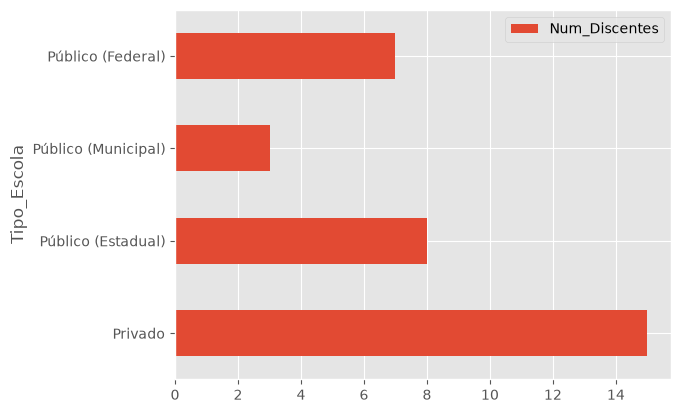

In [3]:
# Gráfico de barras (tipo de escola vs. num. de discentes)
tipo_medio.plot(kind='barh', x='Tipo_Escola', y='Num_Discentes');

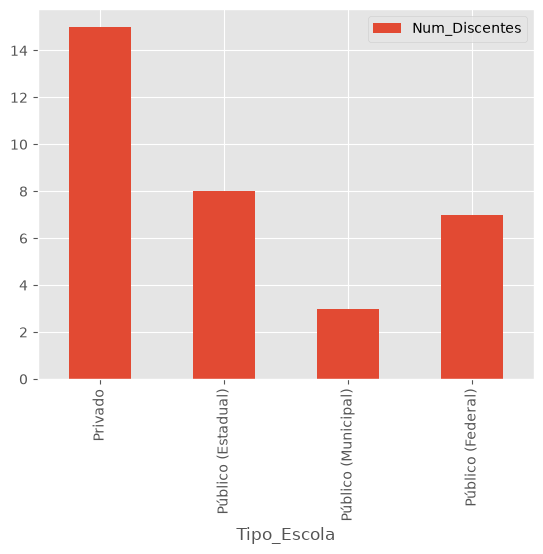

In [4]:
# Gráfico de barras (num. de discentes vs. tipo de escola)
tipo_medio.plot(kind='bar', x='Tipo_Escola', y='Num_Discentes');

### Variáveis ​​numéricas

A distribuição de uma variável numérica nem sempre pode ser representada com precisão por um gráfico de barras, por duas razões comuns:
1. O número de valores distintos assumidos pela variável é grande demais para representarmos em um gráfico;
1. Os valores assumidos pela variável se repetem poucas vezes. 

Como exemplo, vejamos abaixo o número de streams de cada uma das 200 músicas 🎵 mais populares no Spotify nos EUA:

In [5]:
# Carregando o DataFrame
charts = pd.read_csv('https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados/data/regional-us-daily-2023-01-21.csv')

# Atribuindo um índice, criando a coluna `million_streams` e filtrando o DataFrame pelas colunas desejadas 
charts = (charts.set_index('rank')
          .assign(million_streams = np.round(charts.get('streams')/1000000, 2))
          .get(['track_name', 'artist_names', 'streams', 'million_streams'])
         )
charts

,track_name,artist_names,streams,million_streams
rank,,,,
1,Flowers,Miley Cyrus,3356361,2.48
2,Kill Bill,SZA,2479445,1.34
3,Creepin' (with The Weeknd & 21 Savage),"Metro Boomin, The Weeknd, 21 Savage",1337320,1.24
4,Superhero (Heroes & Villains) [with Future & C...,"Metro Boomin, Future, Chris Brown",1235285,1.11
5,Rich Flex,"Drake, 21 Savage",1109704,1.05
...,...,...,...,...
196,"Burn, Burn, Burn",Zach Bryan,267772,0.27
197,LET GO,Central Cee,267401,0.27
198,Major Distribution,"Drake, 21 Savage",266986,0.27


Para ver a distribuição do número de streams, precisamos agrupar pela coluna `'million_streams'`.

In [6]:
# Agrupando por milhões de streams (`million_streams`)
stream_counts = charts.groupby('million_streams').count()
stream_counts = stream_counts.assign(Count=stream_counts.get('track_name')).drop(columns=['track_name', 'artist_names', 'streams'])
stream_counts

,Count
million_streams,
0.27,17
0.28,20
0.29,19
0.30,8
0.31,14
0.32,7
0.33,14
0.34,7
0.35,10


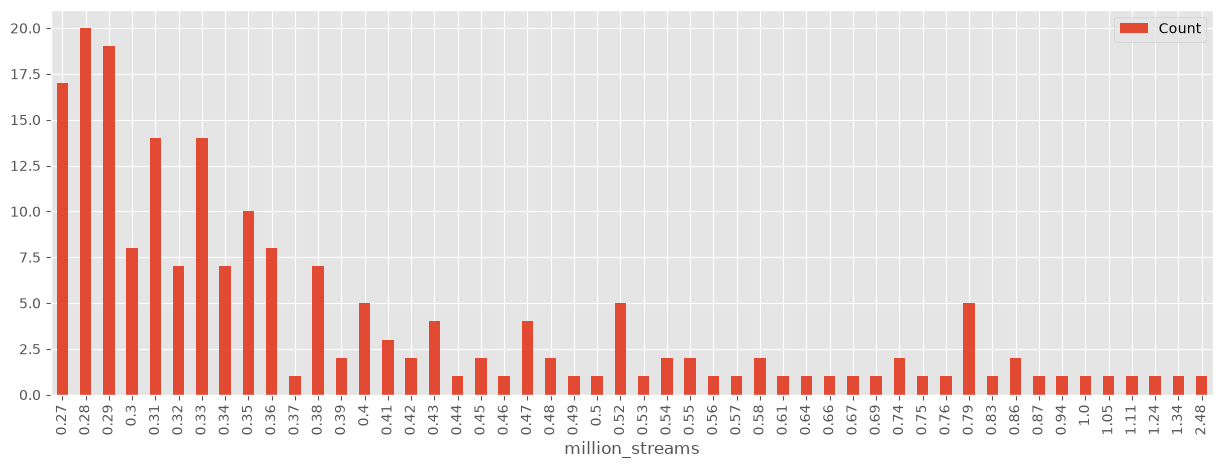

In [7]:
# Gráfico de barras: milhões de streams
stream_counts.plot(kind = 'bar', y = 'Count', figsize = (15, 5));

- Essa visualização não nos mostra um fato crucial sobre esse conjunto, isto é, que as duas músicas mais tocadas são _atípicas_ (_outliers_), com **muito mais streams** do que as outras músicas.
- Para contornar esse problema, faz sentido tomarmos o eixo horizontal como _numérico_, não categórico.
- Além disso, faz mais sentido termos mais espaço entre certas barras do que outras, e dessa maneira agruparmos valores que estejam muito próximos uns dos outros (pois esses poderiam ser considerados equivalentes).

## Histogramas

- Visualizaremos agora a distribuição de uma variável numérica com um **histograma**.

Vamos primeiro ao exemplo: abaixo, temos um _histograma de densidade_ para `'million_streams'`.

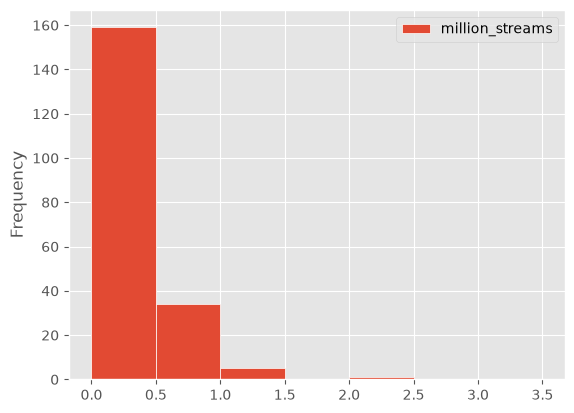

In [8]:
# Ignore e execute o código abaixo.
charts.plot(
    kind = 'hist',
    y = 'million_streams',
    bins = np.arange(0, 4, 0.5),
    ec = 'w'  # borda branca
);

Quais são suas impressões sobre esse gráfico?

#### Construindo um histograma: especificando as classes

- A primeira escolha que devemos fazer ao construir um histograma é escolher as **classes** que formarão esse histograma.
- As classes de um histograma são usualmente intervalos _igualmente espaçados_, mas isso não é estritamente necessário.
- O histograma é essencialmente um gráfico de barras onde os valores da variável numérica são categorizados/classificados em classes apropriadas.

#### Escolha do número de classes

- Como padrão, o Python agrupará os dados em 10 compartimentos de tamanhos iguais.
- Podemos especificar outro número de compartimentos de tamanhos iguais definindo o argumento opcional `bins` igual a algum outro valor inteiro.
- Podemos também especificar classes de tamanho diferentes tomando `bins` como uma sequência de pontos finais dos intervalos que definem cada classe.
    - Nesse último caso, essa sequência pode ser um `array` ou uma `list`, por exemplo.

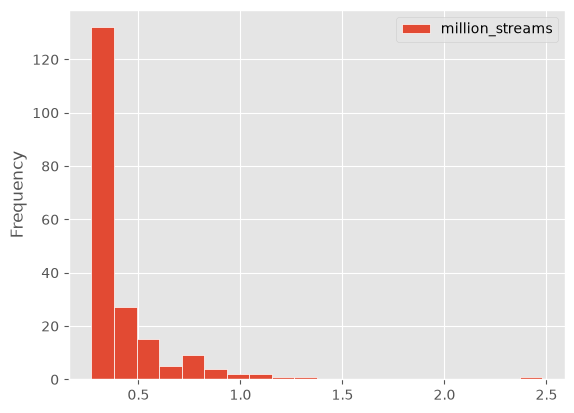

In [9]:
charts.plot(
    kind = 'hist',
    y = 'million_streams',
    bins = 20,
    ec = 'w'
);

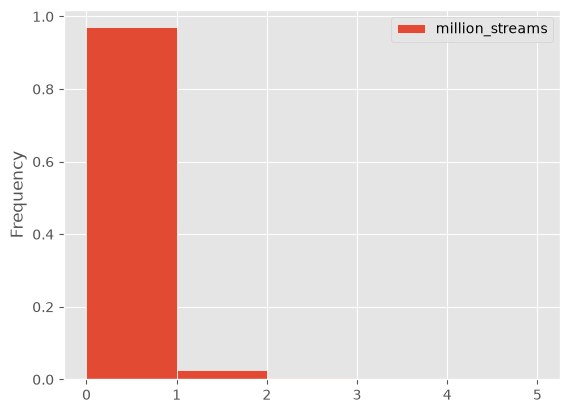

In [10]:
charts.plot(
    kind = 'hist', y = 'million_streams', density = True,
    bins=[0, 1, 2, 3, 4, 5],
    ec = 'w'
);

Você percebe alguma diferença nos histogramas acima?

#### Histogramas de densidade

- A forma geral dos dois histogramas acima é a mesma, independentemente da diferença nas classes.
    - Esta forma é denominada *assimétrica à direita*.
- Quanto mais classes temos um histograma, mais temos uma imagem mais precisa e granular da distribuição da variável em questão.
- Por outro lado, com muitas classes voltamos ao mesmo problema que tínhamos anteriormente com o gráfico de barras!

- Apesar do comportamento geral ser muito similar, note que os valores no eixo $y$ são bem diferentes entre os dois histogramas.
- Isso se deve ao fato de que o primeiro é um **histograma de frequências**, enquanto o segundo é um **histograma de densidade**.

- Em um histograma de densidade, o eixo $y$ pode ser difícil de interpretar, mas foi projetado para dar ao histograma uma propriedade muito boa: **As barras de um histograma de densidade têm uma área total igual a 1**.
- Isso significa que a área de uma barra é igual à proporção (porcentagem) de todos os valores pertencentes à classe correspondente.

#### Exemplo do cálculo de proporções com base em um histograma

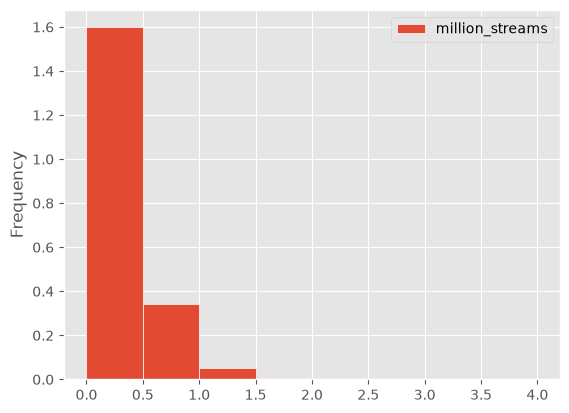

In [11]:
charts.plot(
    kind = 'hist',
    y = 'million_streams',
    density = True,
    bins = [0, 0.5, 1, 1.5, 2.5, 4],
    ec = 'w'
);

Com base neste histograma, qual proporção das 200 músicas mais populares teve menos de meio milhão de streams?

Primeiramente, verificamos que a altura da barra correspondente à classe $[0, 0.5)$ parece ser igual a $1.6$.

Em segundo lugar, a amplitude dessa classe (base do retângulo) é igual a $0.5 - 0 = 0.5$. 

Podemos calcular a proporção dessa classe com base na fórmula da área de um retângulo, isto é,

$$\begin{align}\text{Area} &= \text{Altura} \times \text{Largura} \\ &= 1,6 \times 0,5 \\ &= 0,8
\end{align}$$

Como aqui as áreas representam proporções, isso significa que a proporção das 200 músicas mais populares com menos de 0,5 milhão de streams foi de aproximadamente 0,8 (ou 80\%).

Podemos verificar os cálculos acima diretamente utilizando:

In [12]:
first_bin = charts[charts.get('million_streams') < 0.5].shape[0]
first_bin

159

In [13]:
first_bin/200

0.795

que é próximo o suficiente (lembre que acima tivemos que estimar a altura em $1.6$).

As unidades do eixo $y$ aqui são "proporção por milhão de fluxos", já que o eixo $x$ representa milhões de fluxos.
- Infelizmente, as unidades do eixo $y$ no histograma sempre são exibidas como "Frequência". **Isto está errado!**
- Podemos corrigir com `plt.ylabel(...)`

### Exercício ✅

Suponha que tenhamos criado um histograma de densidade dos tamanhos dos sapatos das pessoas 👟. Abaixo estão as janelas que escolhemos junto com suas alturas:

| Classe | Altura da barra |
| --- | --- |
| [33, 35) | 0.05 |
| [35, 37) | 0.10 |
| [37, 40) | 0.15 |
| [41, 45] | $x$ |


Qual deve ser o valor de $x$ para que este seja um histograma de densidade válido? Preencha a célula de texto abaixo com a resposta correspondente.

**A.** $x = 0.02$

**B.** $x = 0.05$

**C.** $x = 0.20$

**D.** $x = 0.50$

**E.** $x = 0.70$

> ...

### Gráficos de barras vs. histogramas

Gráfico de barras | Histograma
---|---
Mostra a distribuição de uma variável categórica | Mostra a distribuição de uma variável numérica
1 eixo categórico, 1 eixo numérico | 2 eixos numéricos
As barras têm larguras e espaçamentos arbitrários, mas iguais | O eixo horizontal é numérico, e as classes não necessariamente são iguais
Os comprimentos das barras são proporcionais à quantidade numérica de interesse | A altura das barras mede a densidade; as áreas são proporcionais à proporção (porcentagem) de indivíduos

## Gráficos sobrepostos

### Exemplo: populações de San Diego e San Jose ao longo do tempo

- Os dados desse exemplo, para ambas as cidades, vêm de [macrotrends.net](https://www.macrotrends.net/cities/23129/san-diego/population).

In [14]:
population = pd.read_csv('https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados/data/sd-sj-2022.csv').set_index('date')
population

,Pop SD,Growth SD,Pop SJ,Growth SJ
date,,,,
1970,1209000,3.69,1009000,4.34
1971,1252000,3.56,1027000,1.78
1972,1297000,3.59,1046000,1.85
1973,1344000,3.62,1064000,1.72
1974,1392000,3.57,1084000,1.88
1975,1442000,3.59,1103000,1.75
1976,1493000,3.54,1123000,1.81
1977,1547000,3.62,1143000,1.78
1978,1602000,3.56,1163000,1.75


#### Gráficos de linha: população ao longo do tempo

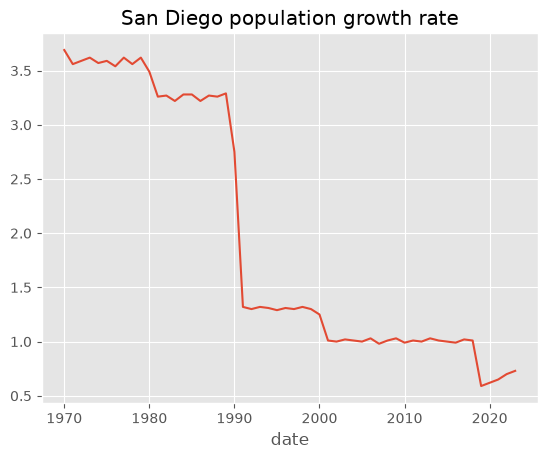

In [15]:
population.plot(kind = 'line', y = 'Growth SD', 
                title = 'San Diego population growth rate', legend = False);

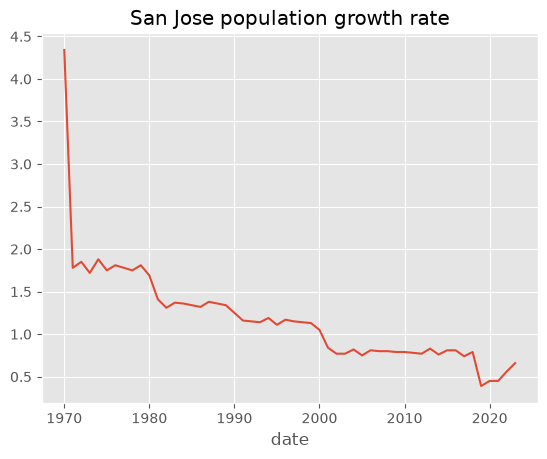

In [16]:
population.plot(kind = 'line', y = 'Growth SJ', 
                title = 'San Jose population growth rate', legend = False);

Note que nos gráficos acima especificamos os argumentos opcionais `title` e `legend`.

Existem [muitos outros argumentos opcionais](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) em um plot: alguns dos mais comuns incluem `figsize`, `xlabel` e `ylabel`.

#### Gráficos de linhas sobrepostos

- Se `y = column_name` for omitido do plot, **todas** as colunas do DataFrame serão plotadas!

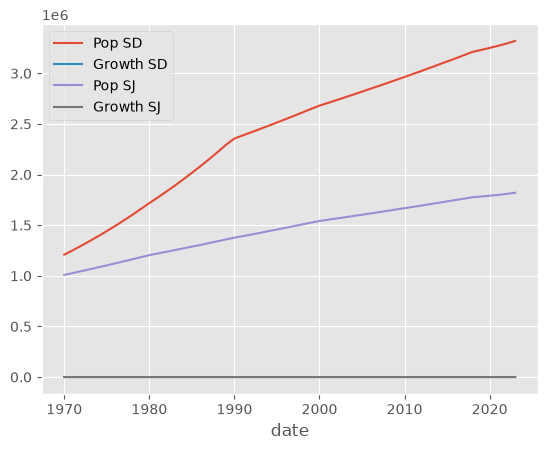

In [17]:
population.plot(kind = 'line');

Nesse exemplo, porém, a diferença de escala entre as variáveis distorce bastante o comportamento em favor das variáveis com valores mais altos.

### Selecionando várias colunas de uma vez

- Para selecionar várias colunas de um DataFrame, utilize `.get([column_1, ..., column_k])`.
- Alterntaivamente, passar uma `lista` de rótulos de colunas como argumento para `.get` também retorna um DataFrame com as colunas desejadas.

In [18]:
growths = population.get(['Growth SD', 'Growth SJ'])
growths

,Growth SD,Growth SJ
date,,
1970,3.69,4.34
1971,3.56,1.78
1972,3.59,1.85
1973,3.62,1.72
1974,3.57,1.88
1975,3.59,1.75
1976,3.54,1.81
1977,3.62,1.78
1978,3.56,1.75


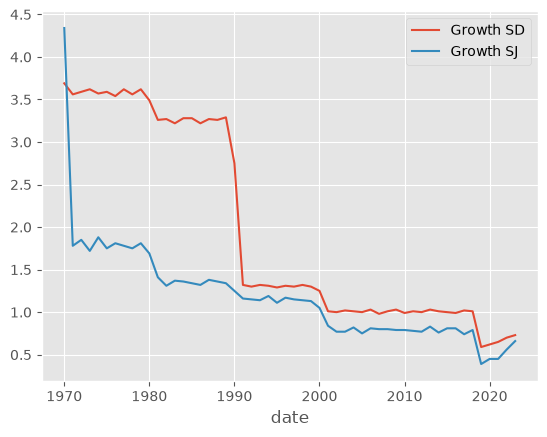

In [19]:
growths.plot(kind = 'line');

- Ao elaborar gráficos sobrepostos, lembre-se sempre de omitir o argumento $y$.
- Quando o DataFrame possui uma coluna de índices, naturalmente esse índice será escolhido para o eixo $x$.
    - Caso contrário, podemos especificar a variável do eixo $x$ através de `.plot(x = column_name)`.
    - Note que não é necessário especificar mais de uma variável para o eixo $x$; todas as variáveis do eixo $y$ compartilharão o mesmo eixo $x$.

### Outro exemplo: alturas das crianças e de seus pais 👪 📏

- Os dados desse exemplo consistem em um conjunto de medidas antropométricas de várias famílias, coletados no final do século XVIII por [Francis Galton](https://en.wikipedia.org/wiki/Francis_Galton).
- Galton foi um dos pioneiros da Eugenia, e essa é uma das principais razões pelas quais ele coletou esses dados.
- A análise sistemática desses dados fez com que Galton recebesse reconhecimento como o descobridor do fenômeno de **regressão à média** em certos fenômenos da natureza, e à técnica de regressão linear em geral.  

Para esse exemplo, selecionaremos apenas duas colunas do DataFrame original: `'mother'` e `'childHeight'`.

In [20]:
mother_child = pd.read_csv('https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados/data/galton.csv').get(['mother', 'childHeight'])
mother_child

,mother,childHeight
0,67.0,73.2
1,67.0,69.2
2,67.0,69.0
3,67.0,69.0
4,66.5,73.5
...,...,...
929,66.0,64.0
930,66.0,62.0
931,66.0,61.0
932,63.0,66.5


#### Histogramas sobrepostos

- A sobreposição de histogramas funciona da mesma maneira como vimos anteriormente: basta ignorar o argumento `'y'` na invocação do `.plot'.
- Quando `kind = 'hist'`, o parâmetro gráfico `alpha` controla o quão _transparentes_ as barras serão (`alpha = 1` é opaco, `alpha = 0` é transparente).

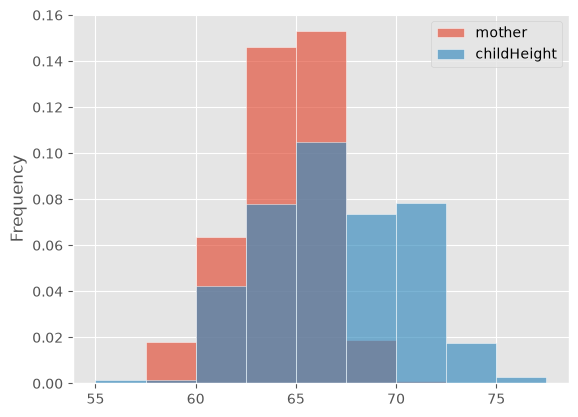

In [21]:
height_bins = np.arange(55, 80, 2.5)
mother_child.plot(kind = 'hist', density = True, ec = 'w',
                  alpha = 0.65, bins = height_bins);

Analisando a sobreposição dos histogramas acima, concluímos que, em média, os filhos são mais altos do que suas mães.

Porém, note que ao escolhermos apenas `'mother'` e `'childHeight'`, ignoramos uma informação bem importante: o sexo dos filhos!

### Exercício ✅

Nas duas células de código abaixo, refaça os histogramas sobrepostos de `'mother'` e `'childHeight'`, mas agora filtrando pelo sexo dos filhos (uma célula para os homens e outra para as mulheres). Suas conclusões se mantiveram as mesmas, isto é, em média os filhos realmente parecem ser mais altos que suas mães?

*<u> Dica<u/>: Redeclare o DataFrame, invocando algo do tipo `df = pd.read_csv('https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Mais%20Sobre%20Visualiza%C3%A7%C3%A3o%20de%20Dados/data/galton.csv').get(['mother', 'childHeight', 'gender'])`.*

In [22]:
# Histograma dos filhos do sexo masculino
...

Ellipsis

In [23]:
# Histograma dos filhos do sexo feminino
...

Ellipsis

## Resumo

- A distribuição de uma variável descreve as frequências de ocorrência associadas à cada valor dessa variável no nosso conjunto de dados.  
- Os histogramas são ferramentas utilizadas para visualizar a distribuição de uma variável numérica.
- Nos histogramas de densidade, a área de uma barra representa a proporção (porcentagem) dos valores dentro da classe correspondente.
- Podemos sobrepor vários gráficos de linhas, gráficos de barras e histogramas uns sobre os outros para observar os relacionamentos entre diferentes distribuições.